In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import MessagesState
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

True

In [3]:
def add(a, b):
    '''
    Add two numbers
    '''
    return a+b

def multiply(a, b):
    '''
    Multiply two numbers
    '''
    return a*b

def divide(a,b):
    '''
    Divide two numbers
    '''
    return a/b

llm = ChatGoogleGenerativeAI(model = "gemini-2.0-flash")
tools = [add, multiply, divide]

llm_bound = llm.bind_tools(tools)

In [13]:
def llm_call(state: MessagesState):
    return {"messages": llm_bound.invoke(state["messages"])}

In [14]:
graph = StateGraph(MessagesState)

graph.add_node("llm_call", llm_call)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "llm_call")
graph.add_conditional_edges(
    "llm_call",
    tools_condition
)
graph.add_edge("tools", "llm_call")

wf = graph.compile()

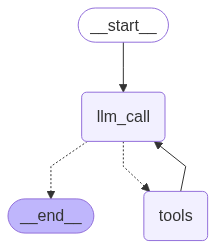

In [15]:
wf

In [18]:
from langchain_core.messages import HumanMessage
final_state = wf.invoke({"messages":[HumanMessage("add 2 and 3, then multiply the result with 5, divide the result with 3")]})

In [19]:
for m in final_state["messages"]:
    m.pretty_print()

================================ Human Message =================================

add 2 and 3, then multiply the result with 5, divide the result with 3
================================== Ai Message ==================================
Tool Calls:
  add (3f187179-62b0-4920-bbdd-ebab478c7ad3)
 Call ID: 3f187179-62b0-4920-bbdd-ebab478c7ad3
  Args:
    a: 2.0
    b: 3.0
================================= Tool Message =================================
Name: add

5.0
================================== Ai Message ==================================
Tool Calls:
  multiply (818b9b34-f4e8-4126-828e-0d040c1f81fb)
 Call ID: 818b9b34-f4e8-4126-828e-0d040c1f81fb
  Args:
    a: 5.0
    b: 5.0
================================= Tool Message =================================
Name: multiply

25.0
================================== Ai Message ==================================
Tool Calls:
  divide (a9f81336-6f9c-4a7d-948e-b640dbbe4ad2)
 Call ID: a9f81336-6f9c-4a7d-948e-b640dbbe4ad2
  Args:
    a: 25.0
    b:

In [11]:
final_state

{'messages': [HumanMessage(content='add 2 and 3, then multiply it with 5, divide the result with 3', additional_kwargs={}, response_metadata={}, id='311666be-7e5b-4424-a84d-2f2664141b5e'),
  AIMessage(content="Okay, let's break this down step-by-step:\n\n1.  **Add 2 and 3:** 2 + 3 = 5\n\n2.  **Multiply the result with 5:** 5 * 5 = 25\n\n3.  **Divide the result with 3:** 25 / 3 = 8.333333333333334\n\nSo the answer is approximately **8.33**", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--61197437-c397-4730-949c-fa18897919d0-0', usage_metadata={'input_tokens': 20, 'output_tokens': 105, 'total_tokens': 125, 'input_token_details': {'cache_read': 0}})]}